# 5. Evaluasi Model (Ujian Akhir dengan Data Test)
Tahapan pada notebook ini:
1. Menyiapkan `test_generator` dengan parameter `shuffle=False` agar urutan prediksi tidak acak dan sesuai dengan kunci jawaban.
2. Memuat (*load*) model terbaik yang sudah disimpan sebelumnya (`resnet50_best_model.h5`).
3. Melakukan prediksi pada data uji (*test*) yang belum pernah dilihat model sama sekali.
4. Menghasilkan *Classification Report* (Presisi, Recall, F1-Score) dan memvisualisasikan *Confusion Matrix*.
5. Menginterpretasikan hasil untuk mengetahui kelas mana yang paling sering salah ditebak oleh model.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

# 1. Menyiapkan Test Generator
# Ingat: Hanya di-rescale, TANPA augmentasi, dan WAJIB shuffle=False
test_datagen = ImageDataGenerator(rescale=1./255)

test_dir = '../dataset/processed/test'

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  
)

class_names = list(test_generator.class_indices.keys())
print(f"\nKelas yang akan diprediksi: {class_names}")

Found 2276 images belonging to 3 classes.

Kelas yang akan diprediksi: ['COVID', 'Normal', 'Viral_Pneumonia']


In [2]:
# 2. Memuat Model Terbaik dari file .h5
model_path = '../models/resnet50_best_model.h5'
print(f"Memuat model dari: {model_path}...\n")

model = load_model(model_path)
print("Model berhasil dimuat!")

# 3. Evaluasi Akurasi Keseluruhan pada Data Test
print(f"Jumlah data test: {test_generator.samples}")
print("\nMelakukan evaluasi metrik dasar pada data test...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\n=> Akurasi Test Keseluruhan: {test_accuracy * 100:.2f}%")
print(f"=> Nilai Loss pada Test: {test_loss:.4f}")

Memuat model dari: ../models/resnet50_best_model.h5...



Model berhasil dimuat!
Jumlah data test: 2276

Melakukan evaluasi metrik dasar pada data test...
72/72 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8620 - loss: 0.3568

=> Akurasi Test Keseluruhan: 86.20%
=> Nilai Loss pada Test: 0.3568


Sedang memprediksi gambar test satu per satu...

72/72 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

          COVID       0.73      0.85      0.78       543
         Normal       0.94      0.86      0.90      1530
Viral_Pneumonia       0.77      0.95      0.85       203

       accuracy                           0.86      2276
      macro avg       0.81      0.88      0.84      2276
   weighted avg       0.87      0.86      0.86      2276


Grafik Confusion Matrix berhasil disimpan ke folder 'results/confusion_matrix.png'


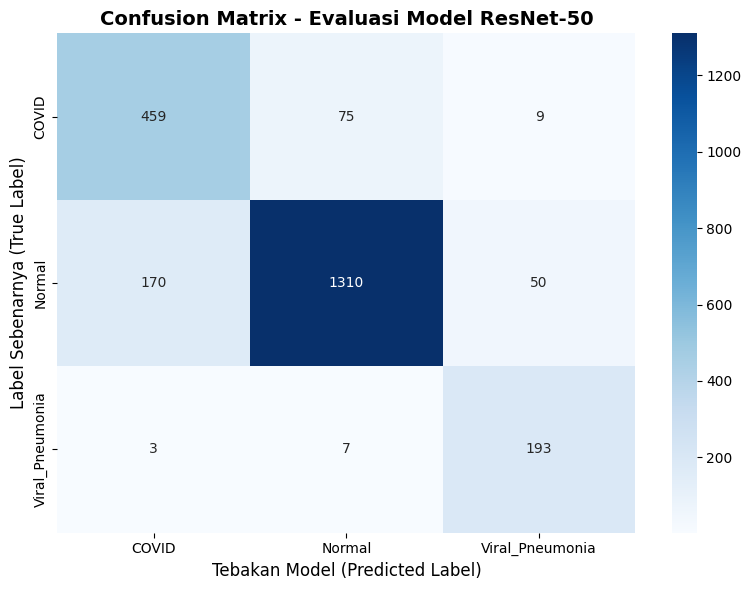

In [3]:
# 4. Melakukan Prediksi
print("Sedang memprediksi gambar test satu per satu...\n")
predictions = model.predict(test_generator, verbose=1)

# Mengubah hasil probabilitas menjadi indeks kelas (0, 1, atau 2)
predicted_classes = np.argmax(predictions, axis=1)

# Mengambil kunci jawaban yang sebenarnya dari test_generator
true_classes = test_generator.classes

# 5. Menampilkan Classification Report
print("\n=== CLASSIFICATION REPORT ===")
report = classification_report(true_classes, predicted_classes, target_names=class_names)
print(report)

# 6. Memvisualisasikan Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes, labels=range(len(class_names)))

plt.figure(figsize=(8, 6))
# Membuat tabel heatmap yang cantik pakai Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Evaluasi Model ResNet-50', fontsize=14, fontweight='bold')
plt.ylabel('Label Sebenarnya (True Label)', fontsize=12)
plt.xlabel('Tebakan Model (Predicted Label)', fontsize=12)

plt.tight_layout()

# Menyimpan hasil Confusion Matrix ke folder results untuk jurnal
plt.savefig('../results/confusion_matrix.png', dpi=300)
print("\nGrafik Confusion Matrix berhasil disimpan ke folder 'results/confusion_matrix.png'")
plt.show()

## Interpretasi Otomatis Hasil Confusion Matrix
Bagian ini menganalisis hasil prediksi untuk menemukan kelemahan spesifik dari model: kelas mana yang paling sering salah ditebak (paling sulit dibedakan oleh AI). Ini sangat berguna untuk pembahasan di dalam jurnal.

In [4]:
# 7. Interpretasi Otomatis Kesalahan Prediksi
# Membuat salinan Confusion Matrix agar yang asli tidak berubah
cm_errors = cm.copy()

# Mengubah nilai diagonal (tebakan yang BENAR) menjadi 0
# Sehingga yang tersisa di matriks hanya angka tebakan yang SALAH
np.fill_diagonal(cm_errors, 0)

# Menghitung total kesalahan per kelas (baris)
salah_tebak_per_kelas = cm_errors.sum(axis=1)

print("=== INTERPRETASI HASIL PREDIKSI ===")
print("Rincian kesalahan tebak (False Negatives) untuk masing-masing kelas:\n")

for i, class_name in enumerate(class_names):
    total_data_asli = cm[i].sum() # Total gambar asli per kelas di data test
    jumlah_salah = salah_tebak_per_kelas[i]
    persentase_salah = (jumlah_salah / total_data_asli) * 100 if total_data_asli > 0 else 0
    
    print(f"- {class_name}: Salah tebak {jumlah_salah} kali dari total {total_data_asli} gambar ({persentase_salah:.2f}% error)")

# Mencari kelas dengan jumlah kesalahan terbanyak
indeks_terburuk = np.argmax(salah_tebak_per_kelas)
kelas_terburuk = class_names[indeks_terburuk]

print(f"\n=> KESIMPULAN UTAMA:")
print(f"Berdasarkan data Test, kelas yang paling sering salah diprediksi (paling sulit dikenali oleh AI) adalah: **{kelas_terburuk.upper()}**.")

=== INTERPRETASI HASIL PREDIKSI ===
Rincian kesalahan tebak (False Negatives) untuk masing-masing kelas:

- COVID: Salah tebak 84 kali dari total 543 gambar (15.47% error)
- Normal: Salah tebak 220 kali dari total 1530 gambar (14.38% error)
- Viral_Pneumonia: Salah tebak 10 kali dari total 203 gambar (4.93% error)

=> KESIMPULAN UTAMA:
Berdasarkan data Test, kelas yang paling sering salah diprediksi (paling sulit dikenali oleh AI) adalah: **NORMAL**.
